In [1]:
# Task 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

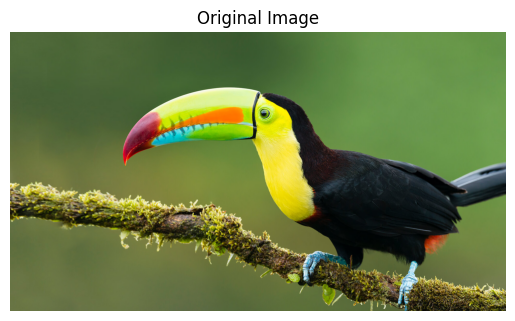

In [2]:
# Task 2: Load and display the image
img_path = "toucan.jpg"
img = Image.open(img_path)
img = img.convert("RGB")
img_np = np.array(img)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
# Task 3: Reshape image into 2D array of pixels
pixels = img_np.reshape(-1, 3)
print("Original shape:", img_np.shape)
print("Reshaped for clustering:", pixels.shape)

Original shape: (1080, 1920, 3)
Reshaped for clustering: (2073600, 3)


In [4]:
# Task 4: Apply K-Means clustering to find 256 color clusters
n_colors = 256
kmeans = KMeans(n_clusters=n_colors, random_state=42)
kmeans.fit(pixels)
cluster_centers = np.uint8(kmeans.cluster_centers_)
labels = kmeans.labels_

In [9]:
labels

array([ 30,  30,  30, ..., 205, 238, 131], shape=(2073600,), dtype=int32)

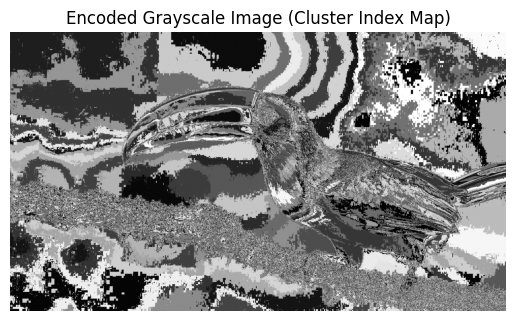

In [5]:
# Task 5: Create encoded (indexed) image representation
encoded_img = labels.reshape(img_np.shape[0], img_np.shape[1])

plt.imshow(encoded_img, cmap='gray')
plt.title("Encoded Grayscale Image (Cluster Index Map)")
plt.axis("off")
plt.show()

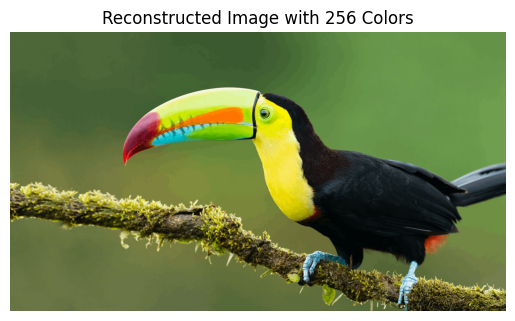

In [6]:
# Task 6: Reconstruct the compressed image using cluster centers
compressed_img = cluster_centers[labels].reshape(img_np.shape)
plt.imshow(compressed_img)
plt.title("Reconstructed Image with 256 Colors")
plt.axis("off")
plt.show()

In [7]:
# Task 7: Calculate Compression Ratio
# Original image: 24 bits per pixel (8 bits per channel × 3)
# Encoded image: log2(256) = 8 bits per pixel (index)
# Plus color map: 256 colors × 24 bits each = 256 × 24 bits total

H, W, _ = img_np.shape
original_size_bits = H * W * 24
encoded_size_bits = (H * W * 8) + (256 * 24)

compression_ratio = original_size_bits / encoded_size_bits
print(f"Original size: {original_size_bits/8/1024:.2f} KB")
print(f"Compressed size (including color map): {encoded_size_bits/8/1024:.2f} KB")
print(f"Compression Ratio: {compression_ratio:.2f} : 1")

Original size: 6075.00 KB
Compressed size (including color map): 2025.75 KB
Compression Ratio: 3.00 : 1


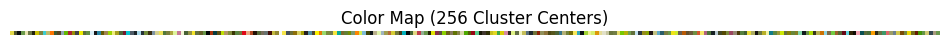

In [8]:
# Task 8: Display color map
plt.figure(figsize=(12, 2))
plt.imshow([cluster_centers])
plt.title("Color Map (256 Cluster Centers)")
plt.axis("off")
plt.show()